# Membership 이탈 유저 분석 EDA

## 이탈(Churn) 정의
- `repurchase == NaN` → **이탈** (구독 후 재구매 없음)
- `repurchase == 'O'` → **잔류** (재구매함)

> 분석 목표: 이탈 유저의 특징을 파악하여 이탈 예측 및 방지 전략 도출

In [2]:
print("HelloWorld!")

HelloWorld!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Membership.csv', encoding='utf-8-sig')
df['reg_date'] = pd.to_datetime(df['reg_date'])
df['end_date']  = pd.to_datetime(df['end_date'])
df['subscription_days'] = (df['end_date'] - df['reg_date']).dt.days
df['dayofweek'] = df['reg_date'].dt.day_name()
df['day_num']   = df['reg_date'].dt.dayofweek

# 이탈 타겟 변수 생성: repurchase가 없으면 이탈(1), 재구매했으면 잔류(0)
df['churn'] = df['repurchase'].isna().astype(int)

print(f'전체: {len(df):,}명')
print(f'이탈: {df["churn"].sum():,}명 ({df["churn"].mean()*100:.1f}%)')
print(f'잔류: {(df["churn"]==0).sum():,}명 ({(df["churn"]==0).mean()*100:.1f}%)')

전체: 18,183명
이탈: 6,252명 (34.4%)
잔류: 11,931명 (65.6%)


## 1. 이탈율 개요

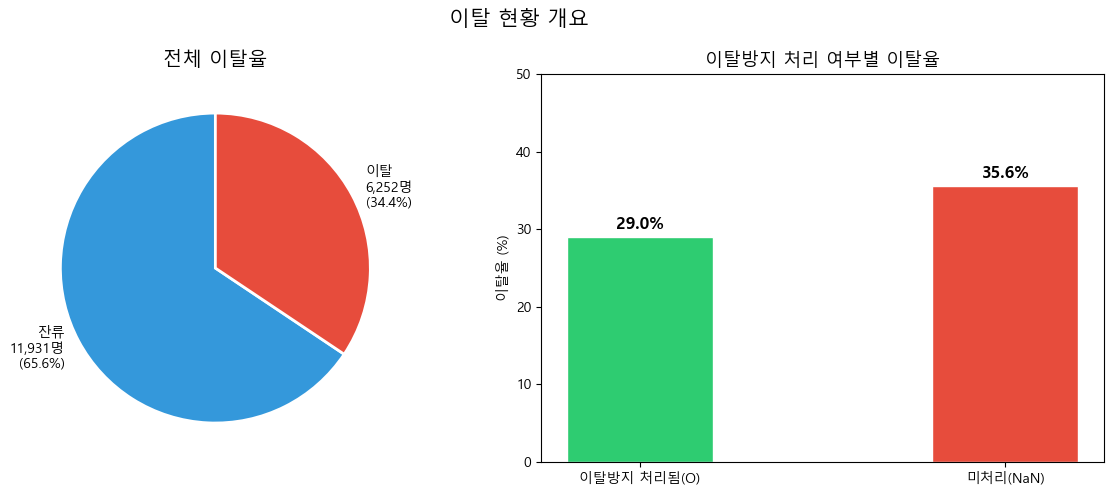

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 파이차트
labels = [f'잔류\n{(df["churn"]==0).sum():,}명\n({(df["churn"]==0).mean()*100:.1f}%)',
          f'이탈\n{df["churn"].sum():,}명\n({df["churn"].mean()*100:.1f}%)']
axes[0].pie([len(df)-df['churn'].sum(), df['churn'].sum()],
            labels=labels, colors=['#3498DB', '#E74C3C'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('전체 이탈율', fontsize=14)

# 이탈방지 처리 효과
churn_by_prevented = df.groupby('is_churn_prevented', dropna=False)['churn'].mean() * 100
churn_by_prevented.index = ['이탈방지 처리됨(O)', '미처리(NaN)']
bars = axes[1].bar(churn_by_prevented.index, churn_by_prevented.values,
                   color=['#2ECC71', '#E74C3C'], edgecolor='white', width=0.4)
axes[1].set_title('이탈방지 처리 여부별 이탈율', fontsize=13)
axes[1].set_ylabel('이탈율 (%)')
axes[1].set_ylim(0, 50)
for bar, v in zip(bars, churn_by_prevented.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('이탈 현황 개요', fontsize=15)
plt.tight_layout()
plt.show()

## 2. 범주형 변수별 이탈율

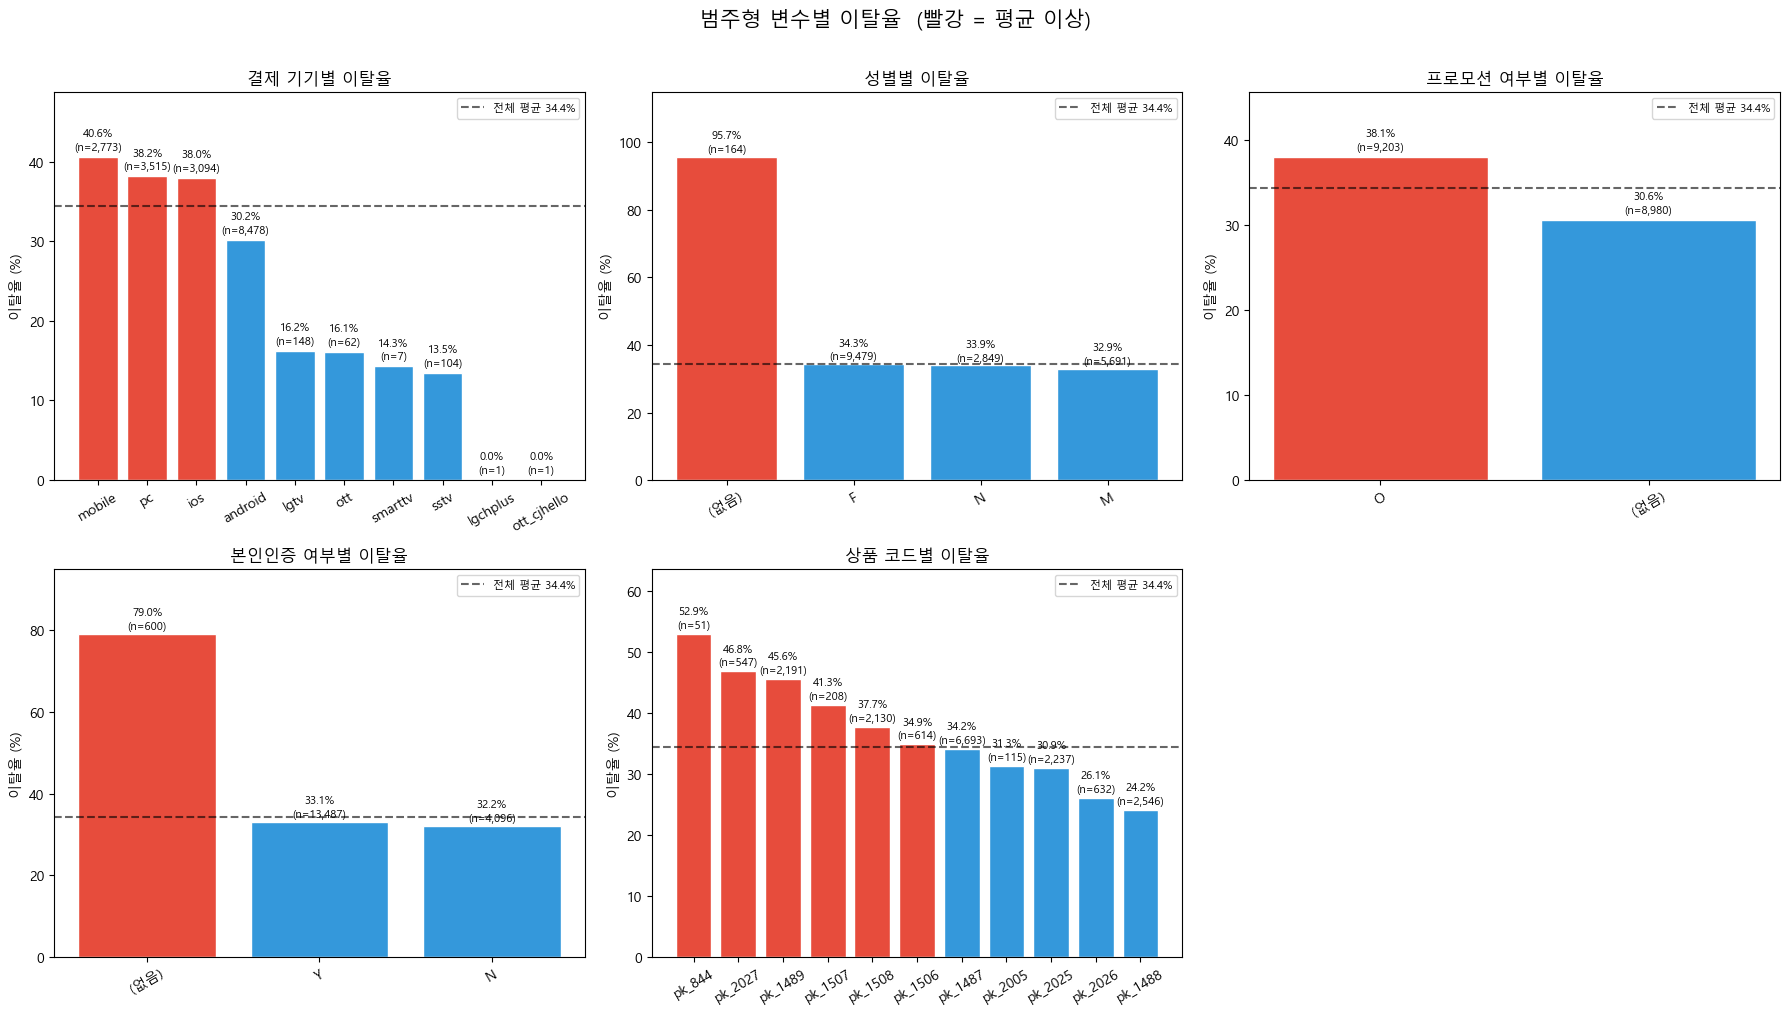

In [20]:
cat_vars = {
    'payment_device': '결제 기기',
    'gender': '성별',
    'promotion_yn': '프로모션 여부',
    'is_user_verified': '본인인증 여부',
    'product_cd': '상품 코드'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (col, title) in enumerate(cat_vars.items()):
    churn_rate = df.groupby(col, dropna=False)['churn'].agg(['mean', 'count']).reset_index()
    churn_rate.columns = [col, 'churn_rate', 'count']
    churn_rate['churn_rate'] *= 100
    churn_rate = churn_rate.sort_values('churn_rate', ascending=False)
    churn_rate[col] = churn_rate[col].fillna('(없음)').astype(str)

    # 상품코드는 건수 많은 것만
    if col == 'product_cd':
        churn_rate = churn_rate[churn_rate['count'] >= 50]

    ax = axes[idx]
    colors = ['#E74C3C' if v > df['churn'].mean()*100 else '#3498DB'
              for v in churn_rate['churn_rate']]
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['churn_rate'],
                  color=colors, edgecolor='white')
    ax.axhline(df['churn'].mean()*100, color='black', linestyle='--',
               alpha=0.6, label=f'전체 평균 {df["churn"].mean()*100:.1f}%')
    ax.set_title(f'{title}별 이탈율', fontsize=12)
    ax.set_ylabel('이탈율 (%)')
    ax.set_ylim(0, max(churn_rate['churn_rate']) * 1.2)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for bar, v, n in zip(bars, churn_rate['churn_rate'], churn_rate['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('범주형 변수별 이탈율  (빨강 = 평균 이상)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 3. 수치형 변수별 이탈 분포

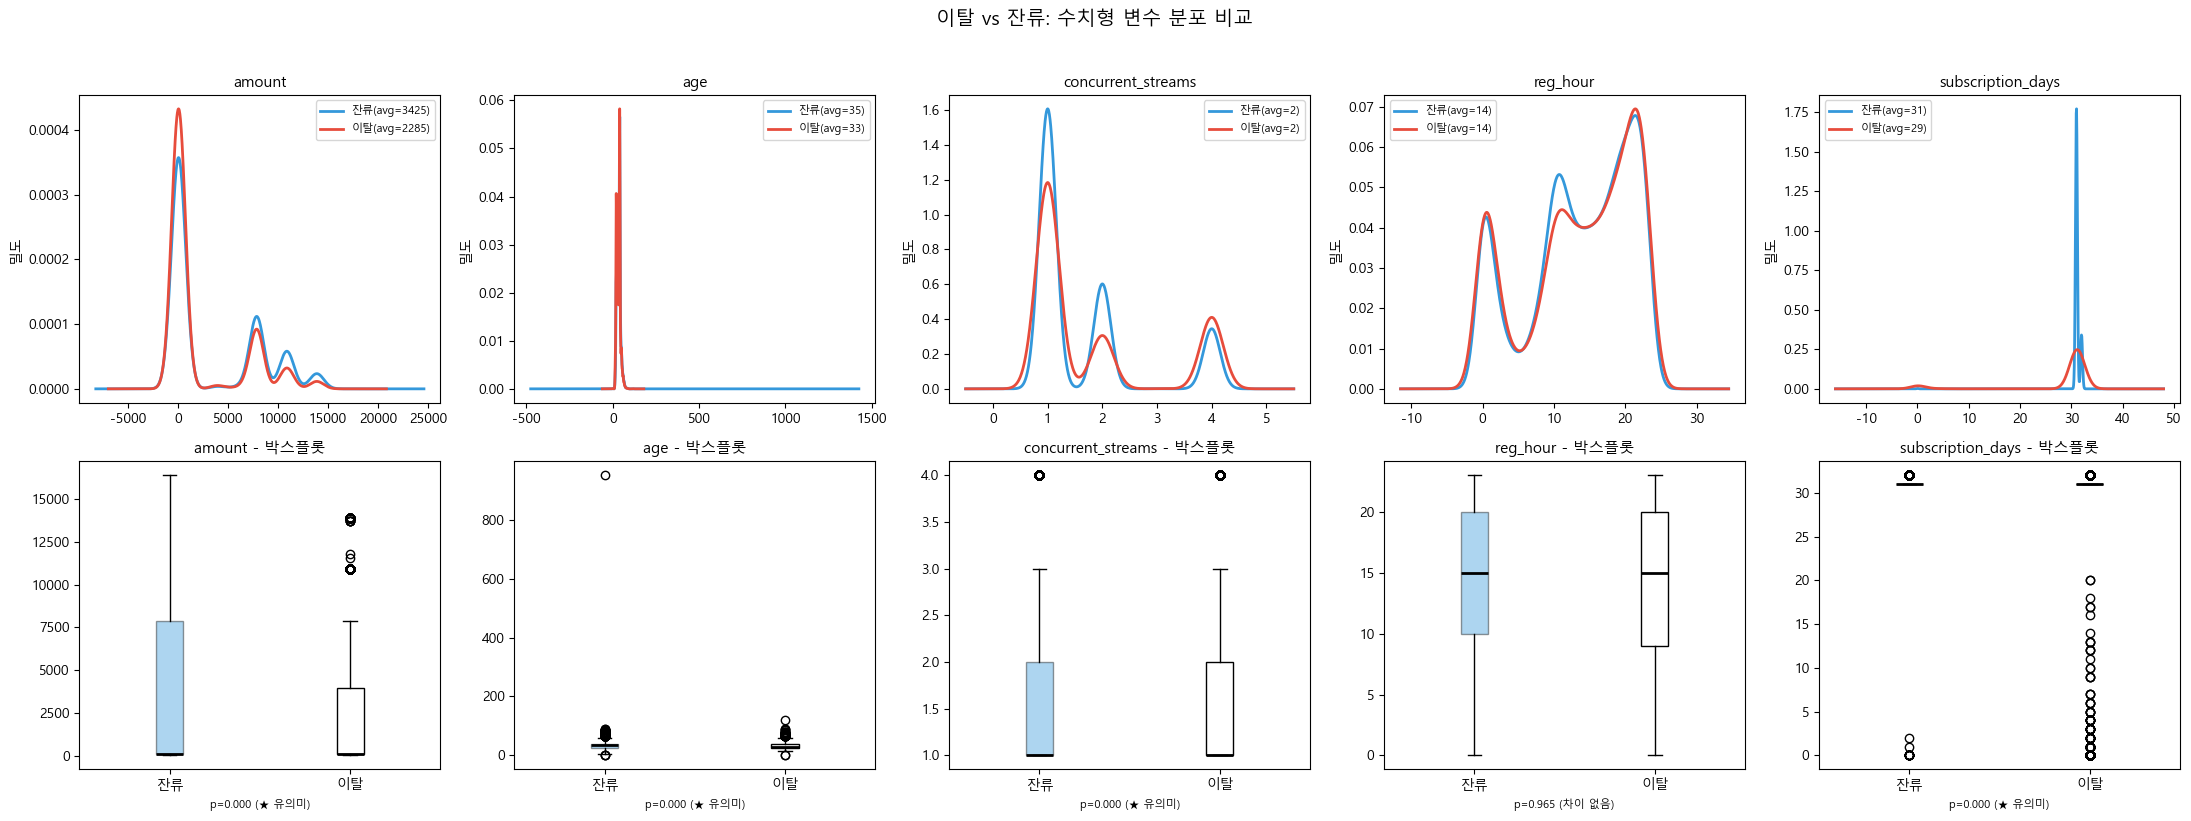

In [21]:
num_vars = ['amount', 'age', 'concurrent_streams', 'reg_hour', 'subscription_days']
churn_0 = df[df['churn'] == 0]
churn_1 = df[df['churn'] == 1]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for i, col in enumerate(num_vars):
    d0 = churn_0[col].dropna()
    d1 = churn_1[col].dropna()

    # KDE 비교
    ax = axes[0, i]
    d0.plot.kde(ax=ax, color='#3498DB', linewidth=2, label=f'잔류(avg={d0.mean():.0f})')
    d1.plot.kde(ax=ax, color='#E74C3C', linewidth=2, label=f'이탈(avg={d1.mean():.0f})')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)

    # 박스플롯 비교
    ax2 = axes[1, i]
    ax2.boxplot([d0, d1], patch_artist=True, labels=['잔류', '이탈'],
                boxprops=dict(facecolor='white'),
                medianprops=dict(color='black', linewidth=2))
    ax2.get_children()[0].set_facecolor('#3498DB')
    ax2.get_children()[0].set_alpha(0.4)
    try:
        ax2.get_children()[3].set_facecolor('#E74C3C')
        ax2.get_children()[3].set_alpha(0.4)
    except:
        pass
    ax2.set_title(f'{col} - 박스플롯', fontsize=11)

    # t-검정으로 유의미한 차이인지 확인
    t_stat, p_val = stats.ttest_ind(d0, d1, nan_policy='omit')
    sig = '★ 유의미' if p_val < 0.05 else '차이 없음'
    ax2.set_xlabel(f'p={p_val:.3f} ({sig})', fontsize=8)

plt.suptitle('이탈 vs 잔류: 수치형 변수 분포 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 결제 금액 구간별 이탈율

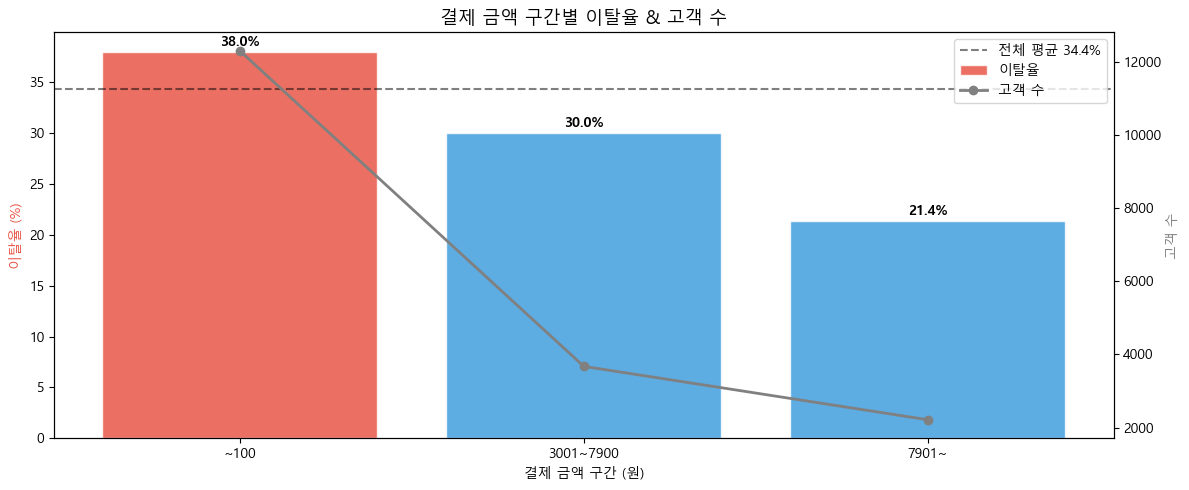

In [22]:
# 금액 구간 분류
bins   = [0, 100, 500, 1000, 3000, 7900, 20000]
labels = ['~100', '101~500', '501~1000', '1001~3000', '3001~7900', '7901~']
df['amount_group'] = pd.cut(df['amount'], bins=bins, labels=labels)

amount_churn = df.groupby('amount_group', observed=True)['churn'].agg(['mean','count']).reset_index()
amount_churn['churn_rate'] = amount_churn['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(amount_churn['amount_group'].astype(str), amount_churn['churn_rate'],
               color=['#E74C3C' if v > df['churn'].mean()*100 else '#3498DB'
                      for v in amount_churn['churn_rate']],
               alpha=0.8, edgecolor='white', label='이탈율')
ax2.plot(amount_churn['amount_group'].astype(str), amount_churn['count'],
         color='gray', marker='o', linewidth=2, label='고객 수')

ax1.axhline(df['churn'].mean()*100, color='black', linestyle='--', alpha=0.5,
            label=f'전체 평균 {df["churn"].mean()*100:.1f}%')
ax1.set_title('결제 금액 구간별 이탈율 & 고객 수', fontsize=13)
ax1.set_xlabel('결제 금액 구간 (원)')
ax1.set_ylabel('이탈율 (%)', color='#E74C3C')
ax2.set_ylabel('고객 수', color='gray')

for bar, v, n in zip(bars, amount_churn['churn_rate'], amount_churn['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

## 5. 시계열 이탈 패턴

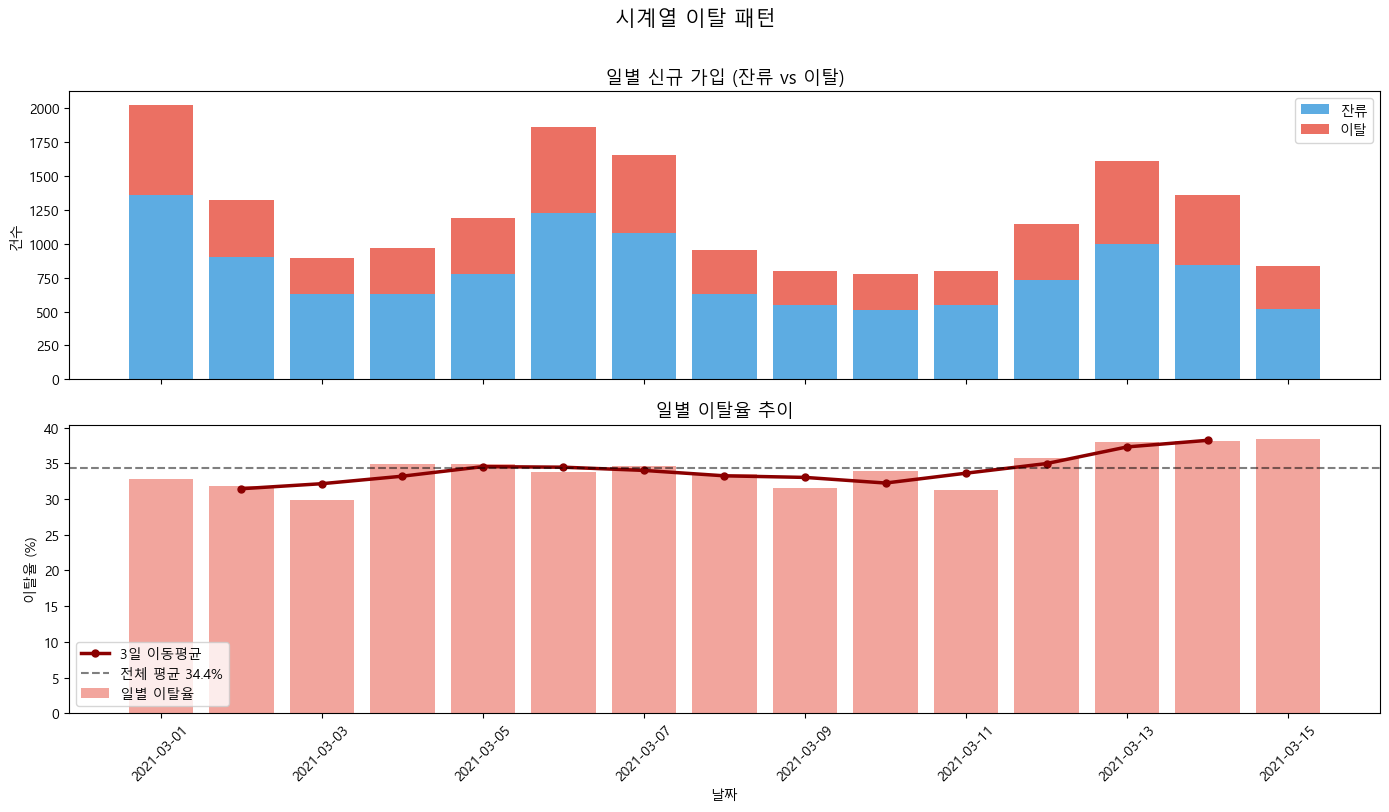

In [23]:
# 일별 가입 건수 & 이탈율 추이
daily = df.groupby('reg_date').agg(
    가입건수=('churn', 'count'),
    이탈수=('churn', 'sum')
).reset_index()
daily['이탈율'] = daily['이탈수'] / daily['가입건수'] * 100
daily['이탈율_MA3'] = daily['이탈율'].rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 가입건수 (잔류 vs 이탈 스택)
bottom = daily['가입건수'] - daily['이탈수']
axes[0].bar(daily['reg_date'], bottom, color='#3498DB', alpha=0.8, label='잔류')
axes[0].bar(daily['reg_date'], daily['이탈수'], bottom=bottom,
            color='#E74C3C', alpha=0.8, label='이탈')
axes[0].set_title('일별 신규 가입 (잔류 vs 이탈)', fontsize=13)
axes[0].set_ylabel('건수')
axes[0].legend()

# 이탈율 추이
axes[1].bar(daily['reg_date'], daily['이탈율'], color='#E74C3C', alpha=0.5, label='일별 이탈율')
axes[1].plot(daily['reg_date'], daily['이탈율_MA3'], color='darkred',
             linewidth=2.5, marker='o', markersize=5, label='3일 이동평균')
axes[1].axhline(df['churn'].mean()*100, color='black', linestyle='--',
                alpha=0.5, label=f'전체 평균 {df["churn"].mean()*100:.1f}%')
axes[1].set_title('일별 이탈율 추이', fontsize=13)
axes[1].set_ylabel('이탈율 (%)')
axes[1].set_xlabel('날짜')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('시계열 이탈 패턴', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

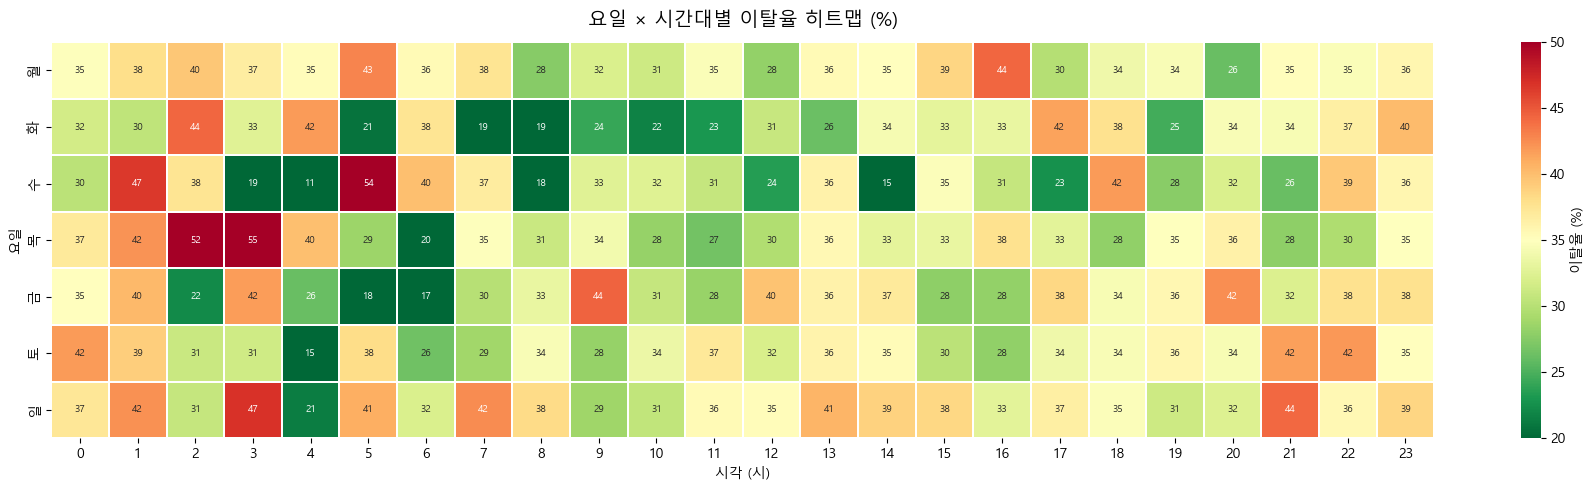

In [24]:
# 요일 × 시간대별 이탈율 히트맵
dow_label = ['월', '화', '수', '목', '금', '토', '일']
pivot_churn = df.groupby(['day_num', 'reg_hour'])['churn'].mean().unstack() * 100
pivot_churn.index = dow_label

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot_churn.round(1), cmap='RdYlGn_r',
            annot=True, fmt='.0f', annot_kws={'size': 7},
            linewidths=0.3, vmin=20, vmax=50, ax=ax,
            cbar_kws={'label': '이탈율 (%)'})
ax.set_title('요일 × 시간대별 이탈율 히트맵 (%)', fontsize=14, pad=12)
ax.set_xlabel('시각 (시)')
ax.set_ylabel('요일')
plt.tight_layout()
plt.show()

## 6. 이탈 고위험군 프로파일링

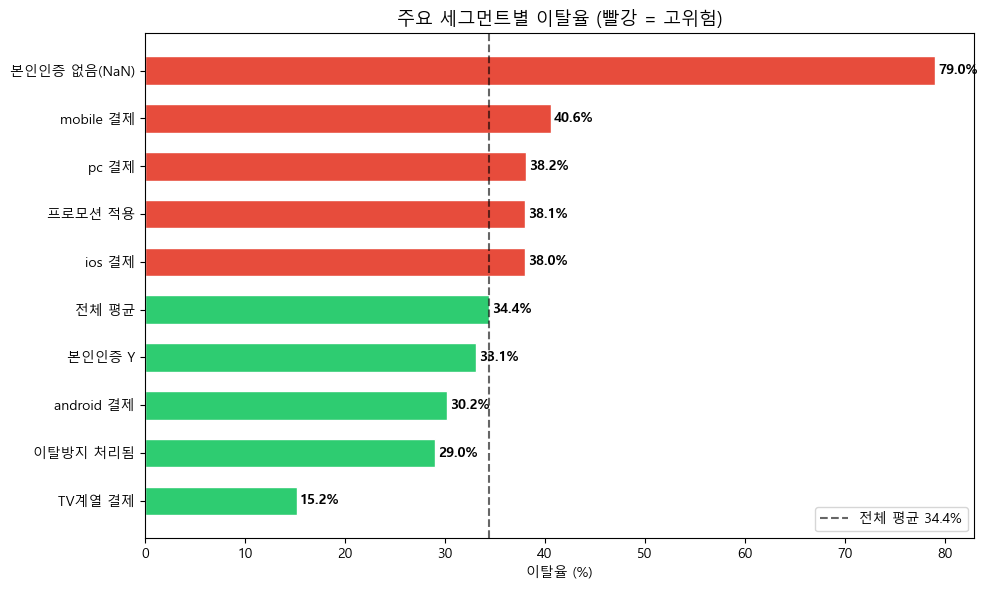

In [25]:
# 주요 변수별 이탈율 정리 (가로 막대 비교)
profile = {
    '본인인증 없음(NaN)': df[df['is_user_verified'].isna()]['churn'].mean(),
    '프로모션 적용': df[df['promotion_yn'] == 'O']['churn'].mean(),
    'mobile 결제': df[df['payment_device'] == 'mobile']['churn'].mean(),
    'pc 결제': df[df['payment_device'] == 'pc']['churn'].mean(),
    'ios 결제': df[df['payment_device'] == 'ios']['churn'].mean(),
    'android 결제': df[df['payment_device'] == 'android']['churn'].mean(),
    'TV계열 결제': df[df['payment_device'].isin(['lgtv','sstv','smarttv','ott','ott_cjhello','lgchplus'])]['churn'].mean(),
    '이탈방지 처리됨': df[df['is_churn_prevented'] == 'O']['churn'].mean(),
    '본인인증 Y': df[df['is_user_verified'] == 'Y']['churn'].mean(),
    '전체 평균': df['churn'].mean(),
}
profile_df = pd.Series(profile).sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C' if v > df['churn'].mean()*100 else '#2ECC71' for v in profile_df.values]
bars = ax.barh(profile_df.index, profile_df.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(df['churn'].mean()*100, color='black', linestyle='--', alpha=0.6,
           label=f'전체 평균 {df["churn"].mean()*100:.1f}%')
ax.set_title('주요 세그먼트별 이탈율 (빨강 = 고위험)', fontsize=13)
ax.set_xlabel('이탈율 (%)')
ax.legend()
for bar, v in zip(bars, profile_df.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

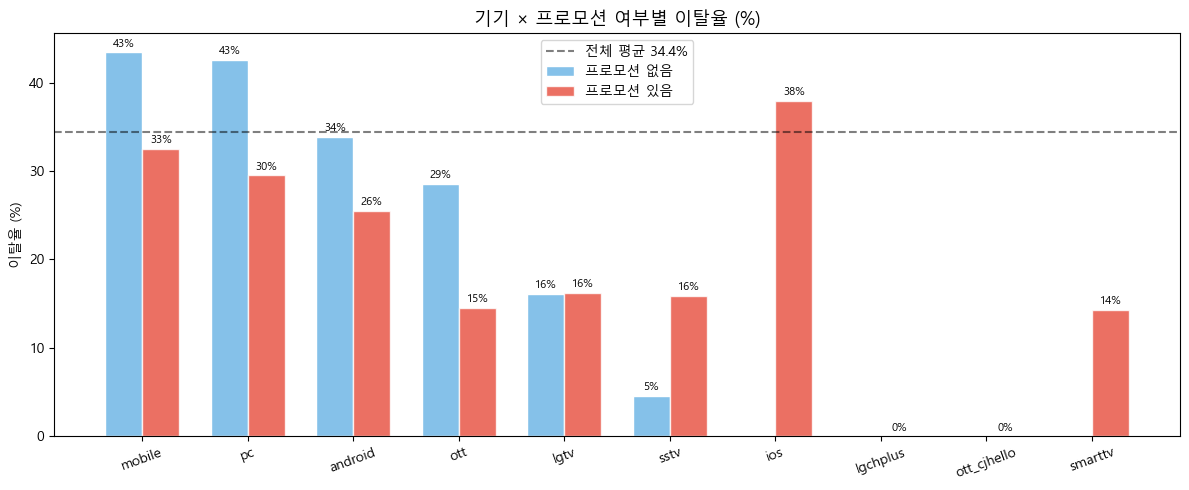

In [26]:
# 복합 조건별 이탈율: 기기 × 프로모션
pivot2 = df.groupby(['payment_device', 'promotion_yn'], dropna=False)['churn'].mean().unstack() * 100
pivot2.columns = ['프로모션 없음(NaN)', '프로모션 있음(O)']
pivot2 = pivot2.sort_values('프로모션 없음(NaN)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pivot2))
w = 0.35
bars1 = ax.bar(x - w/2, pivot2['프로모션 없음(NaN)'], w, label='프로모션 없음',
               color='#85C1E9', edgecolor='white')
bars2 = ax.bar(x + w/2, pivot2['프로모션 있음(O)'],   w, label='프로모션 있음',
               color='#E74C3C', alpha=0.8, edgecolor='white')
ax.axhline(df['churn'].mean()*100, color='black', linestyle='--', alpha=0.5,
           label=f'전체 평균 {df["churn"].mean()*100:.1f}%')
ax.set_xticks(x)
ax.set_xticklabels(pivot2.index, rotation=20)
ax.set_title('기기 × 프로모션 여부별 이탈율 (%)', fontsize=13)
ax.set_ylabel('이탈율 (%)')
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 7. 이탈 유저 요약 인사이트

| 구분 | 이탈율 | 비고 |
|------|--------|------|
| **전체 평균** | 34.4% | 기준선 |
| 본인인증 미완료(NaN) | **79.0%** | ⚠️ 최고 위험 |
| mobile 결제 | **40.6%** | 평균 초과 |
| pc 결제 | **38.2%** | 평균 초과 |
| ios 결제 | **38.0%** | 평균 초과 |
| 프로모션 적용 | **38.1%** | 프로모션 효과 의문 |
| android 결제 | 30.2% | 평균 이하 |
| TV계열 결제 | **13~16%** | ✅ 가장 충성도 높음 |
| 이탈방지 처리 | 29.0% | ✅ 처리 효과 있음 |

### 핵심 인사이트
1. **본인인증 미완료** 유저가 이탈율 79% → 가입 직후 인증 유도 필요
2. **TV계열(lgtv, sstv 등)** 이탈율 13~16% → 가장 충성도 높은 세그먼트
3. **프로모션 적용 유저** 이탈율이 오히려 높음 → 프로모션이 단기 가입을 유도할 수 있음
4. **이탈방지 처리** 유저는 이탈율 감소(35.6% → 29.0%) → 처리 대상 확대 검토
5. **결제 금액 낮은 유저**(평균 2,285원 vs 잔류 3,424원) → 저가 상품 유저 이탈 집중